<a href="https://colab.research.google.com/github/matt-huesman/EE-4940/blob/main/UNet_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mounting Google Drive

In [ ]:
# Mounting google drive to access images
from google.colab import drive
drive.mount('/content/drive')

# Load the (desired) directory
%cd /content/drive/MyDrive/EE_4940


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/EE_4940


In [ ]:
!unzip data/archive.zip

Archive:  data/archive.zip
replace Dataset_BUSI_with_GT/benign/benign (1).png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Dataset_BUSI_with_GT/benign/benign (1).png  
replace Dataset_BUSI_with_GT/benign/benign (1)_mask.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: Dataset_BUSI_with_GT/benign/benign (1)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (10).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (10)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (100).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (100)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (100)_mask_1.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (101).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (101)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (102).png  
  inflating: Dataset_BUSI_with_GT/benign/benign (102)_mask.png  
  inflating: Dataset_BUSI_with_GT/benign/benign (103).png  
  inflating: Dataset_BUSI_with_GT/beni

In [ ]:
!ls data/Dataset_BUSI_with_GT/


benign	malignant  normal


# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage import io
import random
import glob
from PIL import Image


# Load Images and Masks

In [ ]:
masks = glob.glob("data/Dataset_BUSI_with_GT/*/*_mask.png")


In [ ]:
len(masks)

780

In [ ]:
masks[0:3]

['data/Dataset_BUSI_with_GT/benign/benign (104)_mask.png',
 'data/Dataset_BUSI_with_GT/benign/benign (10)_mask.png',
 'data/Dataset_BUSI_with_GT/benign/benign (101)_mask.png']

In [ ]:
images = [mask_images.replace("_mask", "") for mask_images in masks]


In [ ]:
len(images)

780

In [ ]:
images[0:3]

['data/Dataset_BUSI_with_GT/benign/benign (104).png',
 'data/Dataset_BUSI_with_GT/benign/benign (10).png',
 'data/Dataset_BUSI_with_GT/benign/benign (101).png']

In [ ]:
os.path.exists(masks[1])

True

In [ ]:
os.path.exists(images[1])

True

In [ ]:
# make sure all images and masks are accessible
bad_images = []
for image in images:
    if not os.path.exists(image):
        print(f"Image not found: {image}")
        masks.remove(image.replace(".", "_mask."))
        images.remove(image)

bad_masks = []
for mask in masks:
    if not os.path.exists(mask):
        print(f"Mask not found: {mask}")
        images.remove(mask.replace("_mask", ""))
        masks.remove(mask)

In [ ]:
print(len(images), len(masks))

780 780


# Visualize Image Mask pair

In [ ]:
img = io.imread(images[0])

print(img.shape)

(578, 777, 3)


In [ ]:
def plot_image_mask_pair(image_path, mask_path):
    image = io.imread(image_path)
    mask = io.imread(mask_path)

    fig, axes = plt.subplots(1, 3, figsize=(5, 5))

    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('CT')
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Mask')
    axes[1].axis('off')

    axes[2].imshow(image, cmap='gray', alpha=1)
    axes[2].imshow(mask, cmap='gray', alpha=0.5)
    axes[2].set_title('Overlay')
    axes[2].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()


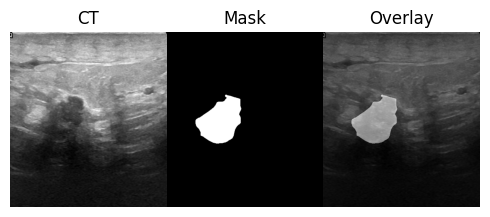

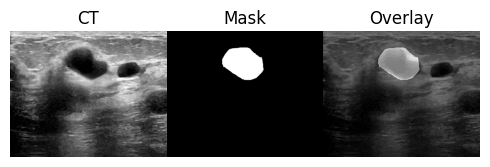

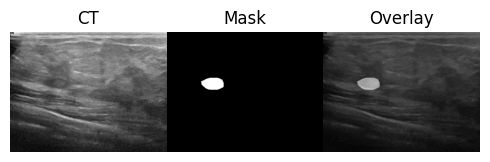

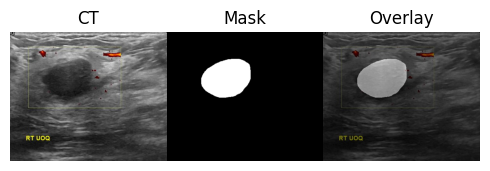

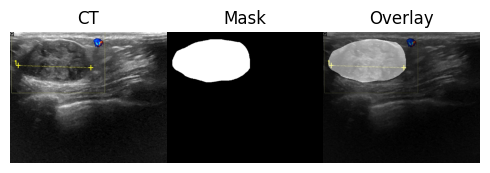

In [ ]:
random_num = random.sample(range(len(masks)), 5)
for num in random_num:
    plot_image_mask_pair(images[num], masks[num])


# Create dataframe in Pandas for image mask pairs

In [ ]:
dataset = pd.DataFrame(zip(images, masks), columns=['images', 'masks'])
dataset.head()


,images,masks
0,data/Dataset_BUSI_with_GT/benign/benign (104).png,data/Dataset_BUSI_with_GT/benign/benign (104)_...
1,data/Dataset_BUSI_with_GT/benign/benign (10).png,data/Dataset_BUSI_with_GT/benign/benign (10)_m...
2,data/Dataset_BUSI_with_GT/benign/benign (101).png,data/Dataset_BUSI_with_GT/benign/benign (101)_...
3,data/Dataset_BUSI_with_GT/benign/benign (100).png,data/Dataset_BUSI_with_GT/benign/benign (100)_...
4,data/Dataset_BUSI_with_GT/benign/benign (103).png,data/Dataset_BUSI_with_GT/benign/benign (103)_...


# Split the dataset into train set and test set

In [ ]:
from sklearn.model_selection import train_test_split

# In the real world, never combine test data into training
train, val = train_test_split(dataset, test_size=0.20)
# val, test = train_test_split(temp, test_size=0.5)

print("Train shape: ", train.shape)    # 80%
print("Validation shape: ", val.shape) # 10%
# print("Test shape: ", test.shape)      # 10%

Train shape:  (624, 2)
Validation shape:  (156, 2)


# Create a custom dataset class

In [ ]:
from torch.utils.data import Dataset
from torchvision import transforms # Import transforms here
from PIL import Image # Ensure PIL Image is imported if not already globally available

# Define a custom transform class to apply the same transformations to both image and mask
class ImageMaskTransform:
    def __init__(self, size):
        self.transform_image = transforms.Compose([
            transforms.Resize(size),
            transforms.ToTensor(),
        ])
        self.transform_mask = transforms.Compose([
            transforms.Resize(size),
            transforms.ToTensor(),
        ])

    def __call__(self, image, mask):
        return self.transform_image(image), self.transform_mask(mask)


class CustomDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.data = dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path = self.data.iloc[idx]['images']
        mask_path = self.data.iloc[idx]['masks']

        # load images and convert to grayscale
        image = Image.open(image_path).convert('L')
        mask = Image.open(mask_path).convert('L')

        if self.transform:
            image, mask = self.transform(image, mask) # This will now call ImageMaskTransform.__call__

        return image, mask

### Create dataloaders

In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms


# transforms performs some manipulation of the data and make it suitable for training
# here we define transformations with augmentation techniques and normalization for grayscale
image_size = 128

# Create an instance of the custom transform
transform = ImageMaskTransform(size=(image_size, image_size))


# Create datasets using the custom transform
train_dataset = CustomDataset(train, transform=transform)
# test_dataset = CustomDataset(test, val_transforms)
val_dataset = CustomDataset(val, transform=transform)

# Create DataLoaders
batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# iterate through train dataloader
for batch in train_dataloader:
    img, mask = batch
    # check the shapes
    print("Input shape:", img.shape)
    print("Target shape:", mask.shape)
    break

Input shape: torch.Size([16, 1, 128, 128])
Target shape: torch.Size([16, 1, 128, 128])


# U-Net



```
# This is formatted as code
```

## U-Net Architecture

The architecture of U-Net is unique in that it consists of a contracting path and an expansive path. The contracting path contains encoder layers that capture contextual information and reduce the spatial resolution of the input, while the expansive path contains decoder layers that decode the encoded data and use the information from the contracting path via skip connections to generate a segmentation map.

The contracting path in U-Net is responsible for identifying the relevant features in the input image. The encoder layers perform convolutional operations that reduce the spatial resolution of the feature maps while increasing their depth, thereby capturing increasingly abstract representations of the input. This contracting path is similar to the feedforward layers in other convolutional neural networks. On the other hand, the expansive path works on decoding the encoded data and locating the features while maintaining the spatial resolution of the input. The decoder layers in the expansive path upsample the feature maps, while also performing convolutional operations. The skip connections from the contracting path help to preserve the spatial information lost in the contracting path, which helps the decoder layers to locate the features more accurately.


More about U-Net: https://www.geeksforgeeks.org/u-net-architecture-explained/

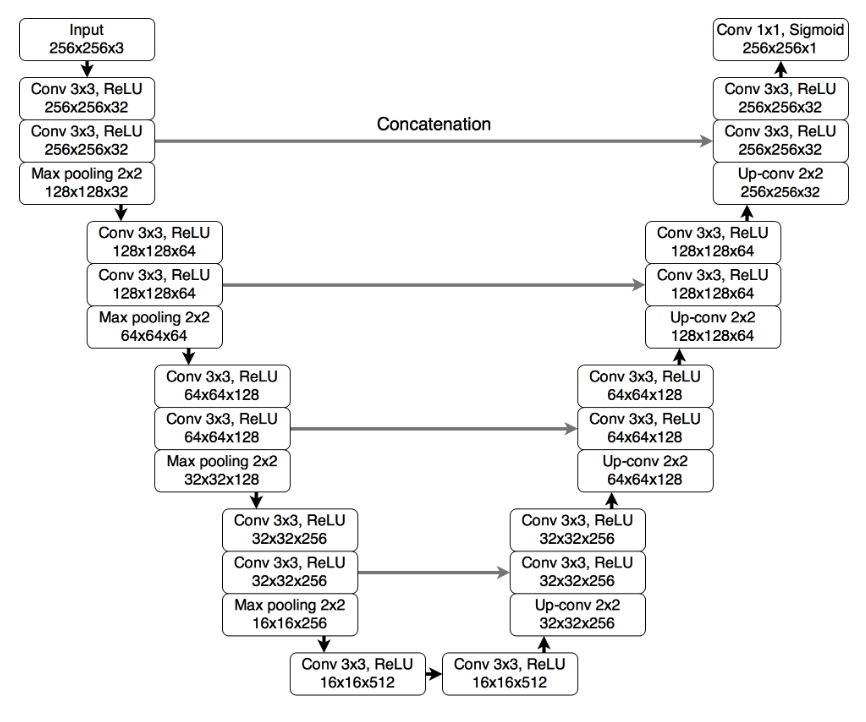

In [ ]:
import torch
import torch.nn as nn


In [ ]:
# first let's check if cuda is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)


cuda:0


## Build U-Net

In [ ]:
# build conv block, encoder and decoder for U-Net

class ConvBlock(nn.Module):
    def __init__(self, input_channel, out_channel, dropout):
        super(ConvBlock, self).__init__()
        self.conv2d_1 = nn.Conv2d(input_channel, out_channel, kernel_size=3, padding=1)
        self.batchnorm_1 = nn.BatchNorm2d(out_channel)
        self.relu_1 = nn.ReLU()

        self.dropout = nn.Dropout(dropout)

        self.conv2d_2 = nn.Conv2d(out_channel, out_channel, kernel_size=3, padding=1)
        self.batchnorm_2 = nn.BatchNorm2d(out_channel)
        self.relu_2 = nn.ReLU()

    def forward(self, x):
        x = self.conv2d_1(x)
        x = self.batchnorm_1(x)
        x = self.relu_1(x)

        x = self.dropout(x)

        x = self.conv2d_2(x)
        x = self.batchnorm_2(x)
        x = self.relu_2(x)

        return x

class Encoder(nn.Module):
    def __init__(self, input_channel, out_channel, dropout):
        super(Encoder, self).__init__()
        self.conv2d_1 = ConvBlock(input_channel, out_channel, dropout)
        self.maxpool = nn.MaxPool2d((2,2))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.conv2d_1(x)
        p = self.maxpool(x)
        p = self.dropout(p)

        return x, p

class Decoder(nn.Module):
    def __init__(self, input_channel, output_channel, dropout):
        super(Decoder, self).__init__()
        self.conv_t = nn.ConvTranspose2d(input_channel, output_channel, stride=2, kernel_size=2)
        self.conv2d_1 = ConvBlock(output_channel*2, output_channel, dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, skip):
        x = self.conv_t(x)
        x = torch.cat([x, skip], dim=1)
        x = self.dropout(x)
        x = self.conv2d_1(x)

        return x


In [ ]:
# create Unet class

class Unet(nn.Module):
    def __init__(self, input_channel=1):
        super().__init__()
        self.encoder_1 = Encoder(input_channel, 64, 0.07)
        self.encoder_2 = Encoder(64, 128, 0.08)
        self.encoder_3 = Encoder(128, 256, 0.09)
        self.encoder_4 = Encoder(256, 512, 0.1)

        self.conv_block = ConvBlock(512, 1024, 0.11)

        self.decoder_1 = Decoder(1024, 512, 0.1)
        self.decoder_2 = Decoder(512, 256, 0.09)
        self.decoder_3 = Decoder(256, 128, 0.08)
        self.decoder_4 = Decoder(128, 64, 0.07)

        self.cls = nn.Conv2d(64, 1, kernel_size=1, padding=0)
        self.relu = nn.Sigmoid()

    def forward(self, x):

        """ ------ Encoder ------"""
        x1, p1 = self.encoder_1(x)
        x2, p2 = self.encoder_2(p1)
        x3, p3 = self.encoder_3(p2)
        x4, p4 = self.encoder_4(p3)

        """ ------ BottleNeck ------"""
        x5 = self.conv_block(p4)

        """ ------ Decoder ------"""
        x6 = self.decoder_1(x5, x4)
        x7 = self.decoder_2(x6, x3)
        x8 = self.decoder_3(x7, x2)
        x9 = self.decoder_4(x8, x1)

        """ ------ Final Layer ------"""
        x_final = self.cls(x9)
        x_final = self.relu(x_final)

        return x_final


# Define Loss function

The Dice coefficient is a common metric for pixel segmentation that can also be modified to act as a loss function.

BCE Dice loss combines Dice loss with the standard binary cross-entropy (BCE) loss that is generally the default for segmentation models. Combining the two methods allows for some diversity in the loss, while benefitting from the stability of BCE.

https://www.kaggle.com/code/bigironsphere/loss-function-library-keras-pytorch

In [ ]:
def dice_coef_loss(pred, target):
    smooth = 1e-6
    intersection = 2.0 * (target*pred).sum() + smooth
    union = target.sum() + pred.sum() + smooth
    return 1 - (intersection/union)

def bce_dice_loss(pred, target):
    dice_score = dice_coef_loss(pred, target)
    bce_loss = nn.BCELoss()
    bce_score = bce_loss(pred, target)
    return bce_score + dice_score


# Train U-Net

In [ ]:
# define dice coeff that measures segmentation overlap
def dice_coeff(pred, target):
    smooth = 1e-5
    intersection = torch.sum(pred * target)
    union = torch.sum(pred) + torch.sum(target)
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice


# train U-Net
def train(train_loader, val_loader, train_parameters):
    epochs = train_parameters['epochs']
    model = train_parameters['model']
    optimizer = train_parameters['optimizer']
    criterion = train_parameters['criterion']
    device = train_parameters['device']

    # create empty lists for training and validation metrics
    train_losses = []
    val_losses = []
    train_dices = []
    val_dices = []

    # to save best model and metrices
    best_model = None
    best_dice = 0.0
    best_epoch = 0

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    for epoch in range(epochs):
        train_loss = 0.0
        val_loss = 0.0
        train_dice = 0.0
        val_dice = 0.0

        # training loop
        for i, (images, masks) in enumerate(train_loader):
            images, masks = images.to(device), masks.to(device)

            # forward pass
            model.train() # set model to training mode
            optimizer.zero_grad() # clears previous gradients
            outputs = model(images)

            # calculate loss
            loss = criterion(outputs, masks)
            dice = dice_coeff(outputs, masks)

            # backward pass (calculate gradients)
            loss.backward()

            # update model weights
            optimizer.step()

            # update loss and dice scores
            train_loss += loss.item()
            train_dice += dice

            if (i + 1) % 20 == 0:
                print(f'Epoch [{epoch + 1}/{epochs}], Step [{i + 1}/{len(train_loader)}], Loss: {loss.item():.4f}, Dice Coef: {dice:.4f}')

        # validation loop
        model.eval() # set model to evaluation mode
        # disables gradient calculation to save memory; no need to update model parameters during validation
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)

                # forward pass (inference)
                outputs = model(images)

                # compute loss and dice score
                val_loss += criterion(outputs, masks).item()
                val_dice += dice_coeff(outputs, masks)

        # calculate average train and validation loss and dice scores
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        avg_train_dice = train_dice / len(train_loader)
        avg_val_dice = val_dice / len(val_loader)

        print(f'Epoch [{epoch + 1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
        print(f'Epoch [{epoch + 1}/{epochs}], Train Dice: {avg_train_dice:.4f}, Val Dice: {avg_val_dice:.4f}')

        # save metrics
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_dices.append(avg_train_dice)
        val_dices.append(avg_val_dice)

        # save best model
        if avg_val_dice > best_dice:
            best_dice = dice
            best_epoch = epoch + 1
            best_model = model.state_dict()

            filename = f'best_model_epoch{best_epoch}_dice{best_dice:.4f}.pth'
            #torch.save(best_model, filename)

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_dices': train_dices,
        'val_dices': val_dices,
        'epochs': epochs,
        'best_model': best_model,
        'best_dice': best_dice,
        'best_epoch': best_epoch
    }





```
# This is formatted as code
```

## Start training

In [ ]:
import torch.optim as optim

unet = Unet(input_channel=1).to(device)
learning_rate = 0.0001
epochs = 10
weight_decay = 1e-6  # regularization to prevent overfitting

optimizer = optim.Adam(unet.parameters(), lr=learning_rate, weight_decay=weight_decay)

train_parameters = {
    'model': unet,
    'epochs': epochs,
    'optimizer': optimizer,
    'criterion': bce_dice_loss,
    'device': device
}



In [ ]:
import time

start_time = time.time()
metrics = train(train_dataloader, val_dataloader, train_parameters)
end_time = time.time()
print(f'Training time: {end_time - start_time:.2f} seconds')



Epoch [1/10], Step [20/39], Loss: 1.3568, Dice Coef: 0.1944
Epoch [1/10], Train Loss: 1.3986, Val Loss: 1.6588
Epoch [1/10], Train Dice: 0.1763, Val Dice: 0.1951
Epoch [2/10], Step [20/39], Loss: 1.0532, Dice Coef: 0.3444
Epoch [2/10], Train Loss: 1.1604, Val Loss: 1.4890
Epoch [2/10], Train Dice: 0.2523, Val Dice: 0.2233
Epoch [3/10], Step [20/39], Loss: 1.1085, Dice Coef: 0.2391
Epoch [3/10], Train Loss: 1.0878, Val Loss: 1.2183
Epoch [3/10], Train Dice: 0.2785, Val Dice: 0.2639
Epoch [4/10], Step [20/39], Loss: 1.1213, Dice Coef: 0.2135
Epoch [4/10], Train Loss: 1.0225, Val Loss: 1.0223
Epoch [4/10], Train Dice: 0.3051, Val Dice: 0.2869
Epoch [5/10], Step [20/39], Loss: 0.8013, Dice Coef: 0.4641
Epoch [5/10], Train Loss: 0.9783, Val Loss: 1.0379
Epoch [5/10], Train Dice: 0.3281, Val Dice: 0.2937
Epoch [6/10], Step [20/39], Loss: 0.8647, Dice Coef: 0.4052
Epoch [6/10], Train Loss: 0.9417, Val Loss: 1.0073
Epoch [6/10], Train Dice: 0.3423, Val Dice: 0.2939
Epoch [7/10], Step [20/39], 

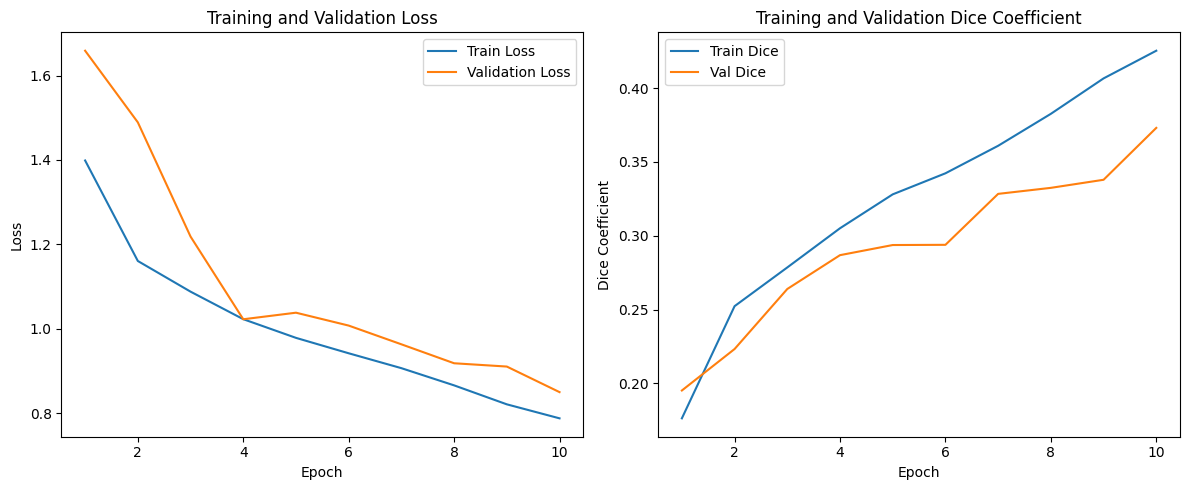

In [ ]:
# plot training and validation loss and dice cofficient
def plot_metrics(metrics):
    train_losses = metrics['train_losses']
    val_losses = metrics['val_losses']
    # convert tensors to NumPy arrays
    train_dices = [dice.cpu().detach().item() for dice in metrics['train_dices']]
    val_dices = [dice.cpu().detach().item() for dice in metrics['val_dices']]
    epochs = np.arange(1, metrics['epochs'] + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(epochs, train_losses, label='Train Loss')
    axes[0].plot(epochs, val_losses, label='Validation Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Plot Dice Coefficients
    axes[1].plot(epochs, train_dices, label='Train Dice')
    axes[1].plot(epochs, val_dices, label='Val Dice')
    axes[1].set_title('Training and Validation Dice Coefficient')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Coefficient')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_metrics(metrics)


In [ ]:
# to save the plot
plt.savefig('metrics.png')

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def to_numpy(tensor):
    # convert tensor to cpu and then NumPy array
    return tensor.cpu().detach().numpy()

def get_threshold(predicted, threshold=0.5):
    predicted[predicted < threshold] = 0
    predicted[predicted >= threshold] = 1
    return predicted

def plot_inferences(image, mask, pred, threshold=0.5):
    # Convert tensors to NumPy arrays
    image_np, mask_np, pred_np = map(to_numpy, (image, mask, pred))

    # threshold the predicted values
    pred_threshold = get_threshold(pred_np, threshold)

    # plot image, mask, and prediction
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    titles = ['Image', 'Mask', 'Predicted']
    for ax, data, title in zip(axes, [image_np, mask_np, pred_np, pred_threshold], titles):
        ax.imshow(data.squeeze(), cmap='gray' if 'Mask' in title else 'gray')
        ax.set_title(title)
        ax.axis('off')

    plt.show()


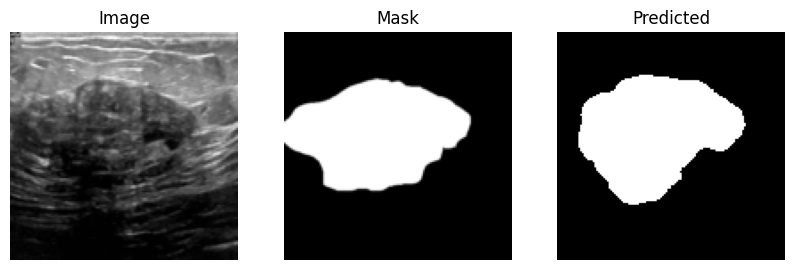

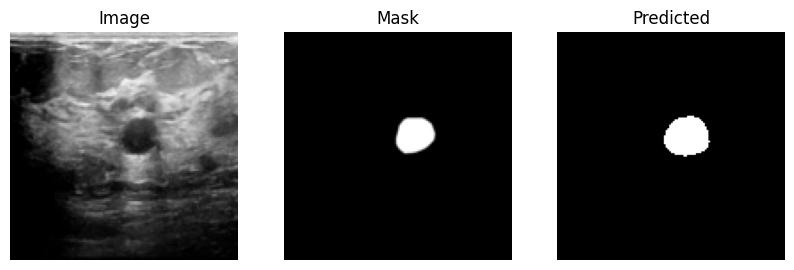

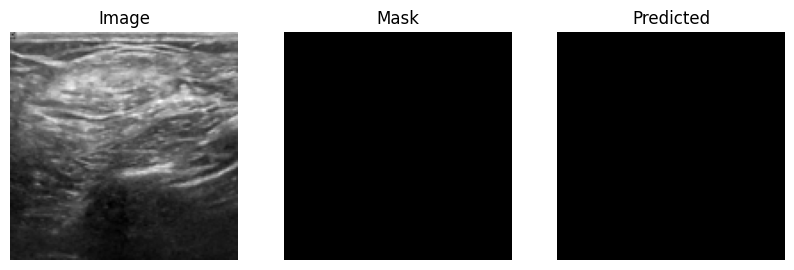

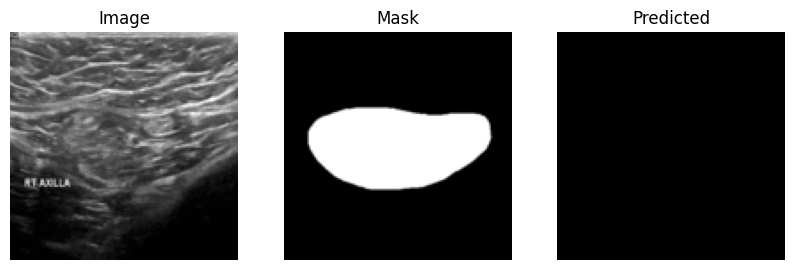

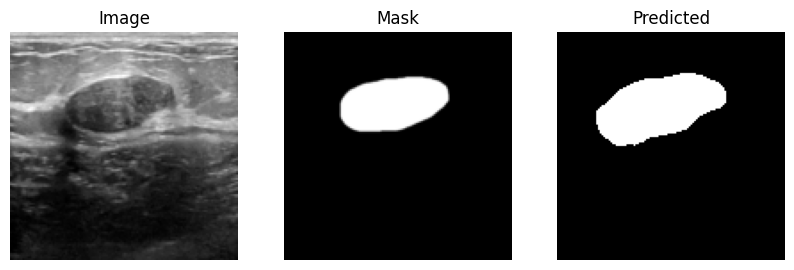

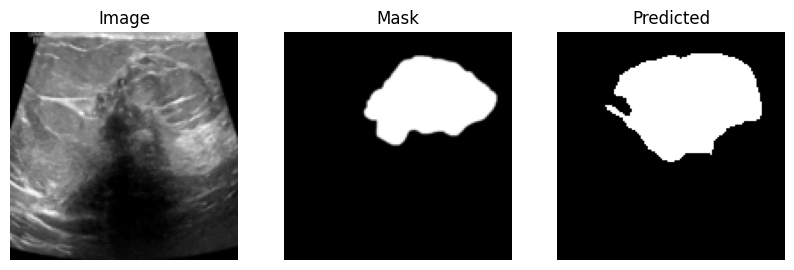

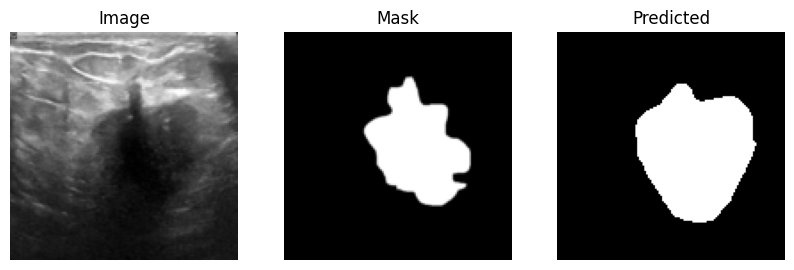

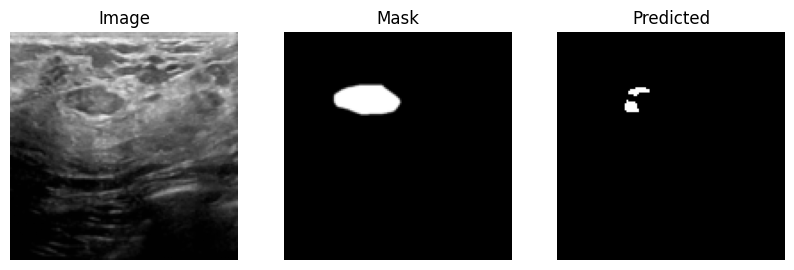

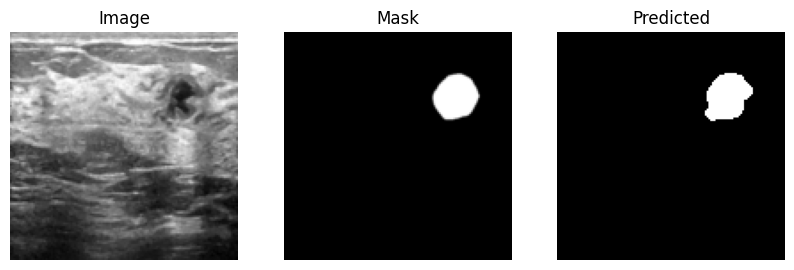

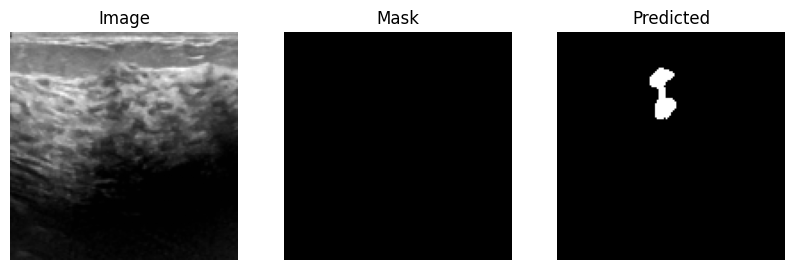

In [ ]:
for i in range(10):
    image = train_dataset[i][0]
    mask = train_dataset[i][1]
    img = image.to(device)
    pred = unet(img.unsqueeze(0))
    pred = pred.squeeze()

    plot_inferences(img, mask, pred)


## Submitting jobs on MSI

```
#!/bin/bash

#SBATCH --job-name=unet
#SBATCH -p msigpu
#SBATCH --gres=gpu:a100:1
#SBATCH --mem-per-cpu=10g
#SBATCH -c 4
#SBATCH --time=00:50:00
#SBATCH --mail-user=mo000007@umn.edu
#SBATCH -o output/unet_%j.output
#SBATCH -e output/unet_%j.error

echo "Training starting......"
source activate torch
python train.py

# using apptainer (container)
#module load apptainer
#apptainer run --nv pytorch_25.02-py3.sif python train.py
```



Save the above script as train.sbatch

Then, submit the job by running: sbatch train.sbatch on msi terminal

# Training with different model

You can try training the dataset with different model. There is a better version of U-Net called U-Net3+ and it claims to have better performance than U-Net.

Here is the github code for U-Net3+:

https://github.com/avBuffer/UNet3plus_pth/blob/master/unet/UNet3Plus.py

# Using pre-trained model

Exercise:

Use a pre-trained u-net model and fine-tune the model and try to increase the dice score.

For example, you can use this pre-trained u-net trained on brain segmentation or find one on [Huggingface](https://huggingface.co/) or [Kaggle](https://www.kaggle.com/).

(Note: pay attention to the model's input channels)


```
import torch
model = torch.hub.load('mateuszbuda/brain-segmentation-pytorch', 'unet',
    in_channels=3, out_channels=1, init_features=32, pretrained=True)
```



# References

Dataset:

https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset/


Pytorch:

https://pytorch.org/tutorials/beginner/basics/data_tutorial.html


U-Net:

https://pytorch.org/hub/mateuszbuda_brain-segmentation-pytorch_unet

https://arxiv.org/abs/1505.04597


U-Net3+:

https://arxiv.org/pdf/2004.08790


